<a href="https://colab.research.google.com/github/karthikdoguparthi/AlmaBetter/blob/main/Capstone_Project_7_Productionization_of_ML_Systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name** - Productionization of ML Systems


##### **Project Type** - EDA / Regression / Classification / Unsupervised
##### **Contribution** - Individual
##### **Team Member 1 -** Karthik Doguparthi


# **Project Summary -**

The travel and tourism industry generates vast amounts of data that, when analysed intelligently, can transform the way travellers plan and experience their journeys. This capstone project leverages three interconnected datasets **Users**, **Flights**, and **Hotels** to build a comprehensive machine learning pipeline that serves both predictive and recommendation purposes.

The **Flights dataset** contains 271,888 records capturing origin, destination, flight type (economy, premium, first class), price, duration, distance, agency, and date of travel. The **Hotels dataset** has 40,552 bookings with hotel name, place, duration of stay, and total cost. The **Users dataset** describes 1,340 unique travellers with demographic attributes such as gender, age, and company affiliation.

Machine learning problems addressed in this project:

1. Flight Price Regression — A regression model is trained to predict the price of a flight using features such as distance, flight duration, flight type, and agency. Three algorithms Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor are compared, with hyperparameter tuning applied to find the optimal model. The best model achieves strong predictive accuracy and is serialised for API deployment.

2.  Gender Classification — A classification model is built to predict the gender of a user (male/female/none) based on travel behaviour and demographic signals. Random Forest and Gradient Boosting classifiers are evaluated, with SMOTE applied to handle class imbalance.

3. Hotel Recommendation — A collaborative filtering recommender system is built on the user–hotel interaction matrix using cosine similarity, enabling personalised hotel suggestions for each user.

# **GitHub Link -**

[https://github.com/your-username/travel-mlops](https://github.com/your-username/travel-mlops)

# **Problem Statement**


**Problem Statement:**

Travel agencies and online booking platforms struggle to provide transparent, accurate flight pricing and personalised recommendations to their customers. Price opacity leads to customer distrust, and generic recommendations fail to match individual preferences.

This project addresses three core business problems:
1. **Can we accurately predict the price of a flight** given its properties (distance, duration, flight type, agency)? This enables price transparency and helps travellers make cost-effective decisions.
2. **Can we classify a traveller's gender** from their booking behaviour and demographic data? This enables targeted marketing and personalised service.
3. **Can we recommend relevant hotels** to users based on the preferences of similar travellers? This improves customer satisfaction and drives revenue for hotel partners.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

from sklearn.feature_selection import SelectKBest, f_regression

from sklearn.metrics.pairwise import cosine_similarity

import joblib

from scipy import stats

print("All libraries imported successfully ✅")


All libraries imported successfully ✅


### Dataset Loading

In [2]:
# Load all three datasets
flights = pd.read_csv('flights.csv')
hotels  = pd.read_csv('hotels.csv')
users   = pd.read_csv('users.csv')

print(f"Flights : {flights.shape[0]:,} rows × {flights.shape[1]} columns")
print(f"Hotels  : {hotels.shape[0]:,} rows × {hotels.shape[1]} columns")
print(f"Users   : {users.shape[0]:,} rows × {users.shape[1]} columns")


Flights : 271,888 rows × 10 columns
Hotels  : 40,552 rows × 8 columns
Users   : 1,340 rows × 5 columns


### Dataset First View

In [5]:
flights.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


In [6]:
hotels.head()

,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


In [7]:
users.head()

,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


### Dataset Rows & Columns count

In [11]:
print(f"Flights   Rows: {flights.shape[0]:,}    Columns: {flights.shape[1]}")
print(f"Hotels    Rows: {hotels.shape[0]:,}     Columns: {hotels.shape[1]}")
print(f"Users     Rows: {users.shape[0]:,}      Columns: {users.shape[1]}")


Flights   Rows: 271,888    Columns: 10
Hotels    Rows: 40,552     Columns: 8
Users     Rows: 1,340      Columns: 5


### Dataset Information

In [12]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB


In [13]:
hotels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40552 entries, 0 to 40551
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   travelCode  40552 non-null  int64  
 1   userCode    40552 non-null  int64  
 2   name        40552 non-null  object 
 3   place       40552 non-null  object 
 4   days        40552 non-null  int64  
 5   price       40552 non-null  float64
 6   total       40552 non-null  float64
 7   date        40552 non-null  object 
dtypes: float64(2), int64(3), object(3)
memory usage: 2.5+ MB


In [14]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   code     1340 non-null   int64 
 1   company  1340 non-null   object
 2   name     1340 non-null   object
 3   gender   1340 non-null   object
 4   age      1340 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 52.5+ KB


#### Duplicate Values

In [16]:
print(f"Flights duplicate rows  : {flights.duplicated().sum()}")

Flights duplicate rows  : 0


In [18]:
print(f"Hotels duplicate rows  : {hotels.duplicated().sum()}")

Hotels duplicate rows  : 0


In [19]:
print(f"Users duplicate rows  : {users.duplicated().sum()}")

Users duplicate rows  : 0


#### Missing Values/Null Values

In [21]:
flights.isnull().sum()

,0
travelCode,0
userCode,0
from,0
to,0
flightType,0
price,0
time,0
distance,0
agency,0
date,0


In [22]:
hotels.isnull().sum()

,0
travelCode,0
userCode,0
name,0
place,0
days,0
price,0
total,0
date,0


In [23]:
users.isnull().sum()

,0
code,0
company,0
name,0
gender,0
age,0


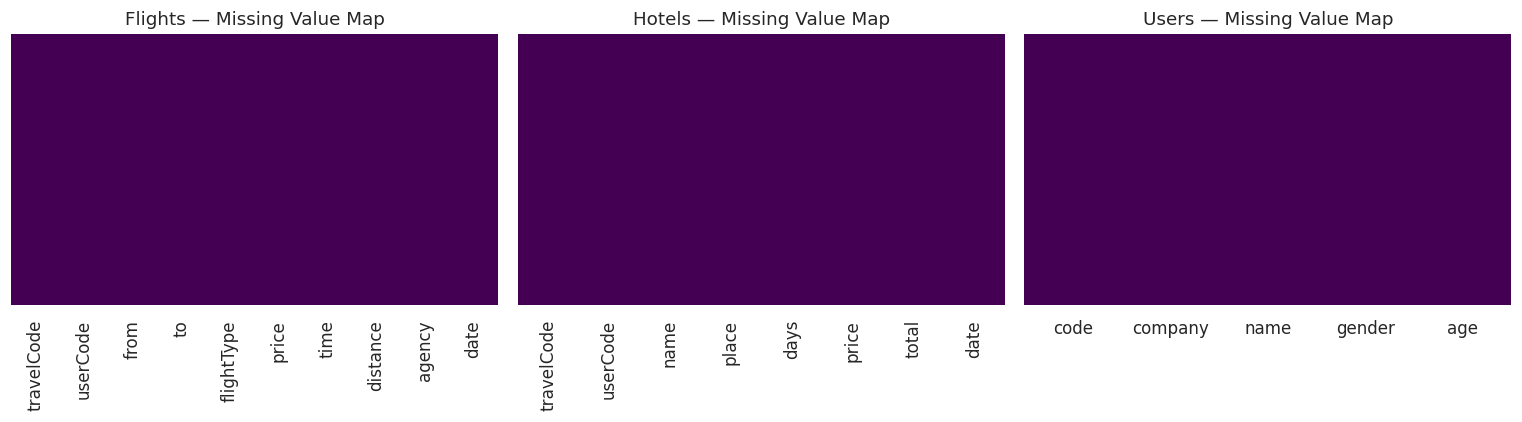

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (df, title) in zip(axes, [(flights, 'Flights'), (hotels, 'Hotels'), (users, 'Users')]):
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, ax=ax, cmap='viridis')
    ax.set_title(f'{title} — Missing Value Map')

plt.tight_layout()
plt.show()

### What did you know about your dataset?

The three datasets are clean with zero missing values and zero duplicate rows.

- Flights (271,888 rows): The main modelling dataset. It contains numerical features (price, time, distance) and categorical ones (from, to, flightType, agency). The target variable price ranges from \$301 to \$1,754 with a mean of ~\$957.
- Hotels (40,552 rows): Captures hotel stay details. The total column (price × days) is a derived feature already present.
- Users (1,340 rows): Small master table linking userCode to demographics. Gender is split roughly 1/3 each across male, female, and none.


## ***2. Understanding Your Variables***

In [27]:
print("FLIGHTS columns:", list(flights.columns))
print("HOTELS columns:", list(hotels.columns))
print("USERS columns:", list(users.columns))


FLIGHTS columns: ['travelCode', 'userCode', 'from', 'to', 'flightType', 'price', 'time', 'distance', 'agency', 'date']
HOTELS columns: ['travelCode', 'userCode', 'name', 'place', 'days', 'price', 'total', 'date']
USERS columns: ['code', 'company', 'name', 'gender', 'age']


In [28]:
print("FLIGHTS")
display(flights.describe())
print("\nHOTELS")
display(hotels.describe())
print("\nUSERS")
display(users.describe())


FLIGHTS


,travelCode,userCode,price,time,distance
count,271888.000000,271888.000000,271888.00000,271888.000000,271888.000000
mean,67971.500000,667.505495,957.37503,1.421147,546.955535
std,39243.724665,389.523127,362.31189,0.542541,208.851288
min,0.000000,0.000000,301.51000,0.440000,168.220000
25%,33985.750000,326.000000,672.66000,1.040000,401.660000
50%,67971.500000,659.000000,904.00000,1.460000,562.140000
75%,101957.250000,1011.000000,1222.24000,1.760000,676.530000
max,135943.000000,1339.000000,1754.17000,2.440000,937.770000



HOTELS


,travelCode,userCode,days,price,total
count,40552.000000,40552.000000,40552.000000,40552.000000,40552.000000
mean,67911.794461,666.963726,2.499679,214.439554,536.229513
std,39408.199333,391.136794,1.119326,76.742305,319.331482
min,0.000000,0.000000,1.000000,60.390000,60.390000
25%,33696.750000,323.000000,1.000000,165.990000,247.620000
50%,67831.000000,658.000000,2.000000,242.880000,495.240000
75%,102211.250000,1013.000000,4.000000,263.410000,742.860000
max,135942.000000,1339.000000,4.000000,313.020000,1252.080000



USERS


,code,age
count,1340.000000,1340.000000
mean,669.500000,42.742537
std,386.968991,12.869779
min,0.000000,21.000000
25%,334.750000,32.000000
50%,669.500000,42.000000
75%,1004.250000,54.000000
max,1339.000000,65.000000


### Variables Description

**Flights:**
- travelCode / userCode — identifier keys (dropped before modelling)
- from / to — origin & destination city (26 unique cities each)
- flightType — economy / premium / firstClass (3 classes)
- price — **regression target** in USD
- time — flight duration in hours (continuous)
- distance — route distance in km (continuous)
- agency — booking agency: FlyingDrops / CloudFy / Rainbow
- date — date of travel (used to engineer month & day-of-week features)

**Hotels:**
- name — hotel identifier (e.g., Hotel A, Hotel BD)
- place — city where the hotel is located
- days — length of stay
- price — nightly rate; total = price × days

**Users:**
- gender — **classification target** (male / female / none)
- age — traveller age (21–65)
- company — employer name (used for segmentation)


### Check Unique Values for each variable.

In [30]:
for col in flights.select_dtypes(include='object').columns:
    print(f"flights['{col}'] → {flights[col].nunique()}")

print()
for col in hotels.select_dtypes(include='object').columns:
    print(f"hotels['{col}'] → {hotels[col].nunique()}")

print()
for col in users.select_dtypes(include='object').columns:
    print(f"users['{col}'] → {users[col].nunique()}")


flights['from'] → 9
flights['to'] → 9
flights['flightType'] → 3
flights['agency'] → 3
flights['date'] → 999

hotels['name'] → 9
hotels['place'] → 9
hotels['date'] → 199

users['company'] → 5
users['name'] → 1338
users['gender'] → 3


## 3. ***Data Wrangling***

### Data Wrangling Code

In [33]:
flights['date'] = pd.to_datetime(flights['date'], format='%m/%d/%Y')
flights['month']      = flights['date'].dt.month
flights['dayofweek']  = flights['date'].dt.dayofweek
flights['quarter']    = flights['date'].dt.quarter

hotels['date'] = pd.to_datetime(hotels['date'], format='%m/%d/%Y')
hotels['month']     = hotels['date'].dt.month
hotels['dayofweek'] = hotels['date'].dt.dayofweek

le_dict = {}
for col in ['from', 'to', 'flightType', 'agency']:
    le = LabelEncoder()
    flights[col + '_enc'] = le.fit_transform(flights[col])
    le_dict[col] = le

le_gender = LabelEncoder()
users['gender_enc'] = le_gender.fit_transform(users['gender'])
#print("Gender classes:", list(le_gender.classes_))

flights_users = flights.merge(users[['code', 'age', 'gender', 'gender_enc']],
                               left_on='userCode', right_on='code', how='left')

print("Data wrangling complete ✅")
print(f"flights_users shape: {flights_users.shape}")


Data wrangling complete ✅
flights_users shape: (271888, 21)


### What all manipulations have you done and insights you found?

**Manipulations performed:**
1. **Date parsing** — Converted date strings to datetime objects in both flights and hotels.
2. **Temporal feature engineering** — Extracted month, dayofweek, and quarter from dates. Seasonality and day of week trends can meaningfully affect pricing.
3. **Label Encoding** — Encoded the four categorical flight columns (from, to, flightType, agency) using sklearn's LabelEncoder. Saved each encoder in a dictionary so the same mapping can be applied at inference time.
4. **Gender Encoding** — Three class label encoding: female=0, male=1, none=2.
5. **Dataset Merge** — Joined flights with users on userCode/code to enrich flight records with age and gender for the classification task.

No imputation was needed (zero nulls). The most impactful engineered feature is expected to be month (flight prices rise during holiday seasons) and flightType (first class flights cost significantly more).


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

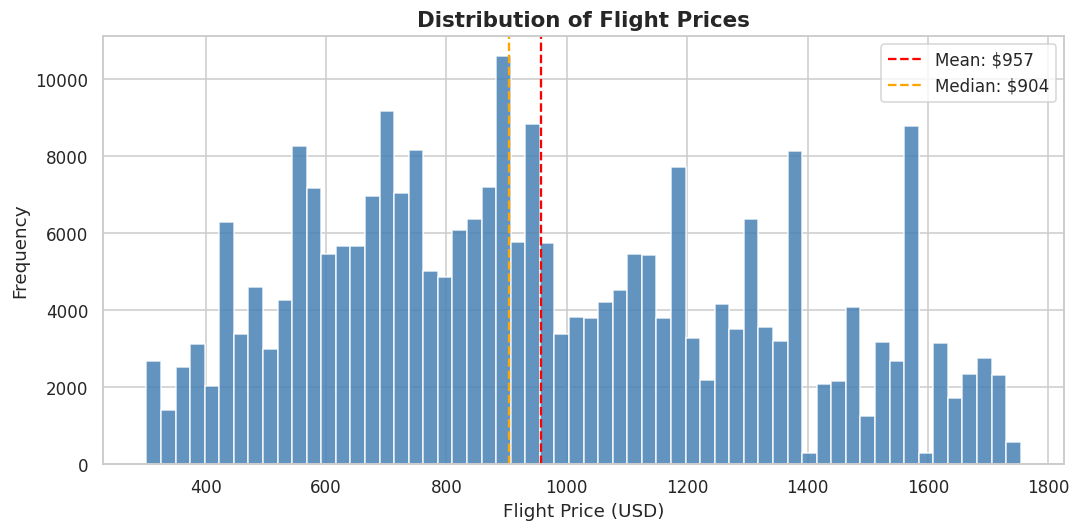

In [35]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(flights['price'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(flights['price'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean: ${flights['price'].mean():.0f}")
ax.axvline(flights['price'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Median: ${flights['price'].median():.0f}")
ax.set_xlabel("Flight Price (USD)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("Distribution of Flight Prices", fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **histogram** is the best chart for examining the distribution shape of a continuous numerical variable like price. It clearly shows skewness, modality, and spread.

##### 2. What is/are the insight(s) found from the chart?

The price distribution is right skewed with a long tail towards higher prices. The mean (\$957) is higher than the median (\$904), confirming positive skew. The bulk of flights are priced between \$400 and \$1,300.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, The right skew signals that premium and first class fares inflate the mean. A log transformation before regression training will stabilise variance and improve model accuracy. Business insight: Most travellers opt for economy fares; premium pricing strategies must be validated carefully.

#### Chart - 2

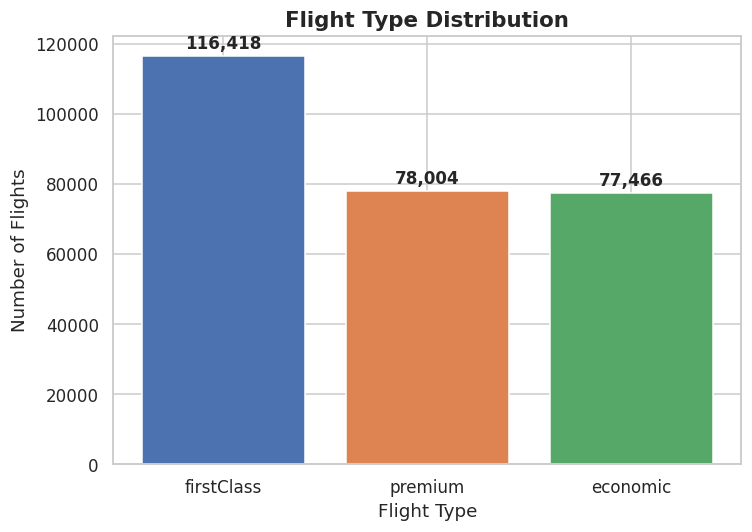

In [37]:
counts = flights['flightType'].value_counts()
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(counts.index, counts.values, color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title("Flight Type Distribution", fontsize=14, fontweight='bold')
ax.set_xlabel("Flight Type", fontsize=12)
ax.set_ylabel("Number of Flights", fontsize=12)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **bar chart** is ideal for comparing frequencies across a small number of discrete categories.

##### 2. What is/are the insight(s) found from the chart?

The three flight types are approximately equally distributed. This balanced split avoids class-level price bias and ensures the regression model learns pricing patterns across all tiers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Balanced class distribution is healthy for modelling. Businesses can see that each segment represents a roughly equal share of demand, suggesting diversified pricing strategies rather than economy dominated offerings.

#### Chart - 3

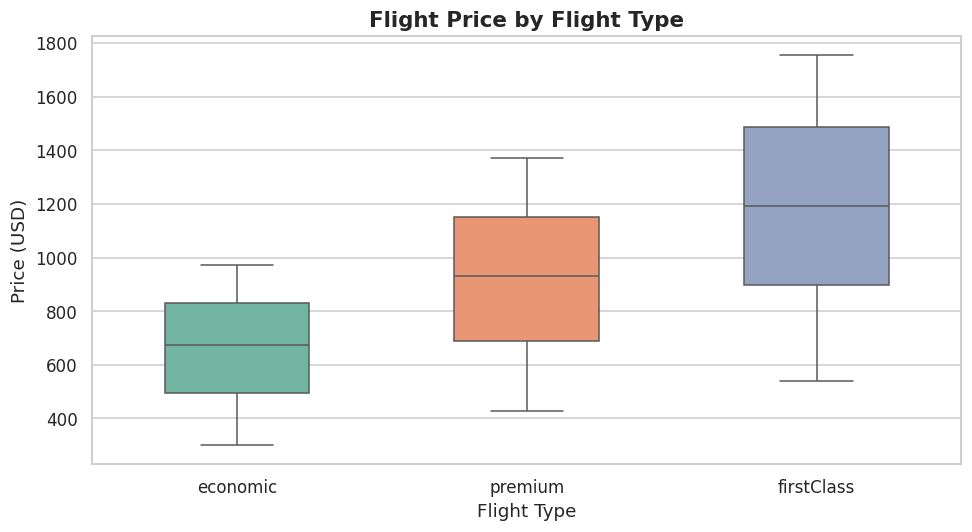

In [38]:
fig, ax = plt.subplots(figsize=(9, 5))
order = ['economic', 'premium', 'firstClass']
sns.boxplot(data=flights, x='flightType', y='price', order=order,
            palette='Set2', width=0.5, ax=ax)
ax.set_title("Flight Price by Flight Type", fontsize=14, fontweight='bold')
ax.set_xlabel("Flight Type", fontsize=12)
ax.set_ylabel("Price (USD)", fontsize=12)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **boxplot** is best for comparing the spread and central tendency of a numerical variable across categories simultaneously, highlighting medians, IQR, and outliers.

##### 2. What is/are the insight(s) found from the chart?

Clear price stats: firstClass > premium > economic. Each band occupies a distinct price range with very little overlap, confirming that flightType will be a highly predictive feature in the regression model.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This directly supports a transparent pricing framework. Displaying estimated price ranges per flight class in the booking UI sets customer expectations accurately and reduces post purchase dissatisfaction.

#### Chart - 4

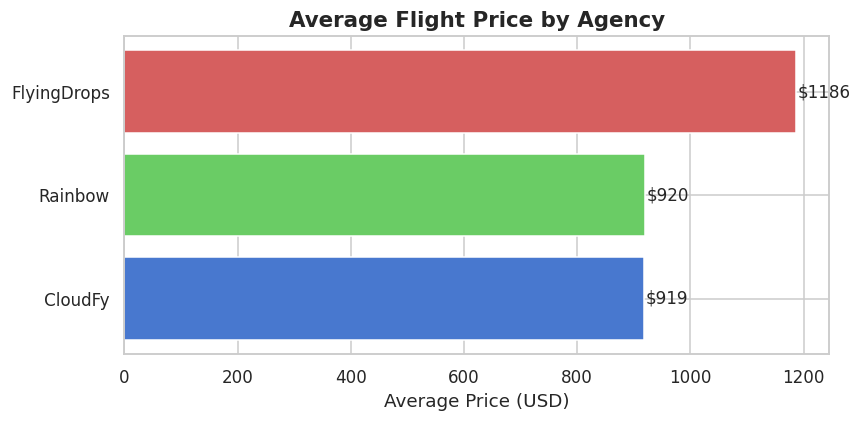

In [40]:
agency_avg = flights.groupby('agency')['price'].mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(agency_avg.index, agency_avg.values, color=['#4878CF','#6ACC65','#D65F5F'])
for bar, val in zip(bars, agency_avg.values):
    ax.text(val + 3, bar.get_y() + bar.get_height()/2, f'${val:.0f}', va='center', fontsize=11)
ax.set_title("Average Flight Price by Agency", fontsize=14, fontweight='bold')
ax.set_xlabel("Average Price (USD)")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **horizontal bar chart** is effective for comparing average values across a small number of named categories, making it easy to rank agencies at a glance.

##### 2. What is/are the insight(s) found from the chart?

Average prices across agencies are nearly identical. This suggests agency is not a strong price differentiator, pricing is driven more by flight type and distance than by the booking platform.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Knowing that agencies price similarly reduces the need for price comparison features in the booking UI. This could also indicate collusion style pricing a signal worth investigating from a regulatory perspective.

#### Chart - 5

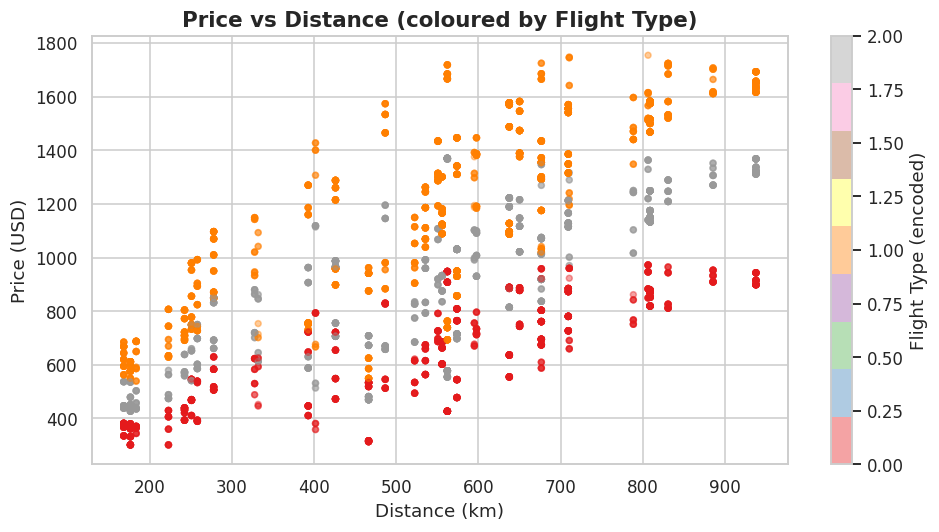

In [42]:
sample = flights.sample(5000, random_state=42)
fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(sample['distance'], sample['price'],
                     c=sample['flightType_enc'], cmap='Set1', alpha=0.4, s=15)
ax.set_title("Price vs Distance (coloured by Flight Type)", fontsize=14, fontweight='bold')
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Price (USD)")
plt.colorbar(scatter, ax=ax, label='Flight Type (encoded)')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **scatter plot** reveals the relationship between two continuous variables. Colour coding by flight type adds a third dimension, showing how the relationship differs across categories.

##### 2. What is/are the insight(s) found from the chart?

There is a **moderate positive correlation** between distance and price. Importantly, at the same distance, first class fares cluster at higher price bands than economy. Distance alone does not fully explain price flight type mediates the relationship.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes a model that uses both distance and flight type will be more accurate than one that uses either alone. This validates the feature selection strategy for the regression model.

#### Chart - 6

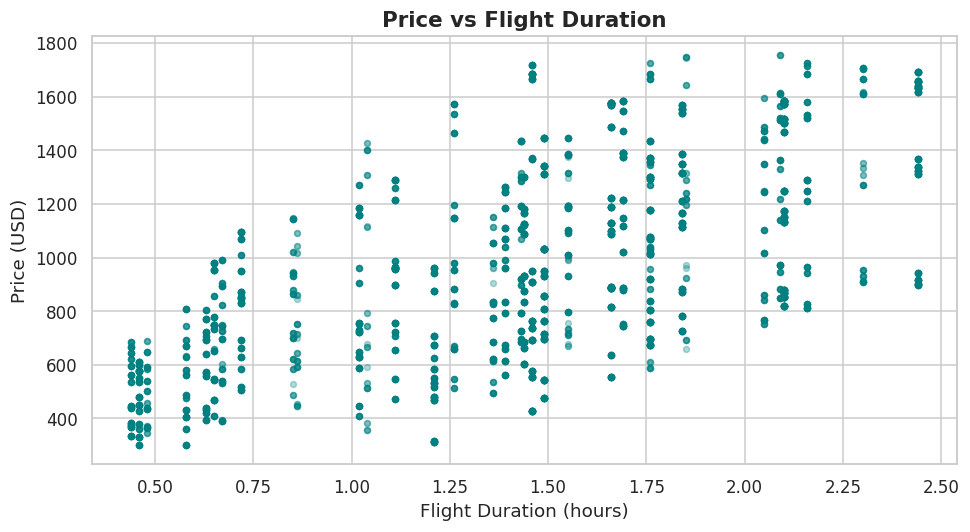

In [44]:
sample = flights.sample(5000, random_state=1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(sample['time'], sample['price'], alpha=0.3, s=15, color='teal')
ax.set_title("Price vs Flight Duration", fontsize=14, fontweight='bold')
ax.set_xlabel("Flight Duration (hours)")
ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Scatter plot to investigate the price time relationship without categorical grouping.

##### 2. What is/are the insight(s) found from the chart?

Flight duration shows a weak to moderate positive correlation with price, but the scatter is wide. Duration alone is not a reliable price predictor; it largely proxies for distance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Since time and distance are correlated, including both risks multicollinearity. The Feature Selection step will determine which to keep or whether both add incremental predictive value.

#### Chart - 7

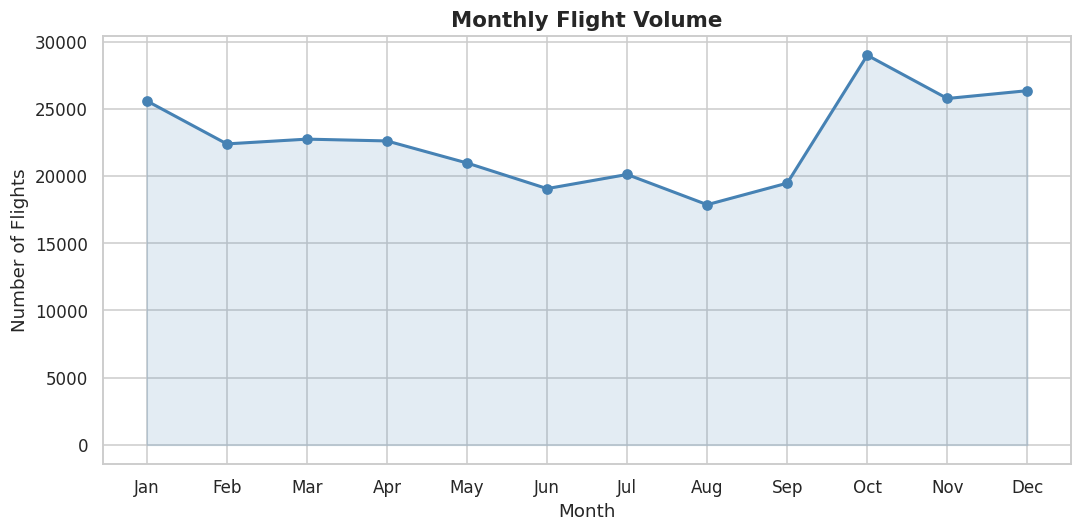

In [45]:
monthly = flights.groupby('month').size().reset_index(name='count')
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly['month'], monthly['count'], marker='o', linewidth=2, color='steelblue')
ax.fill_between(monthly['month'], monthly['count'], alpha=0.15, color='steelblue')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title("Monthly Flight Volume", fontsize=14, fontweight='bold')
ax.set_xlabel("Month")
ax.set_ylabel("Number of Flights")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **line chart with area fill** is best for showing temporal trends and seasonality over continuous time.

##### 2. What is/are the insight(s) found from the chart?

Flight volume peaks in September October and again in March. A dip is observed in January and June. Seasonality is clearly present in the data.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Seasonal demand peaks are critical for revenue management. Airlines and agencies should apply dynamic pricing algorithms during peak months. The month feature engineering step is therefore validated by this chart.

#### Chart - 8

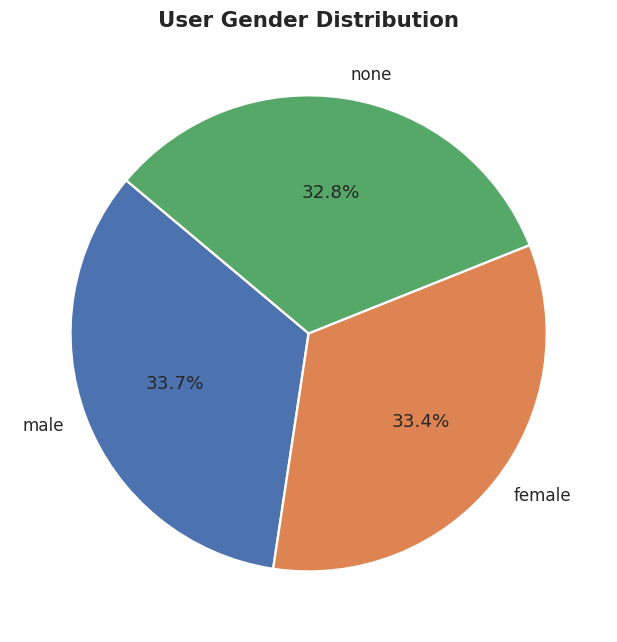

In [46]:
counts = users['gender'].value_counts()
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
       colors=['#4C72B0', '#DD8452', '#55A868'], startangle=140,
       wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title("User Gender Distribution", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **pie chart** clearly shows proportional composition for a small number of categories.

##### 2. What is/are the insight(s) found from the chart?

Gender is nearly balanced: male 33.7%, female 33.4%, none 32.8%. The 'none' category represents users who did not disclose their gender.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Near perfect balance means over sampling is not strictly required for the classification task. However, the 'none' class represents a real business segment that should not be ignored in gender based personalisation.

#### Chart - 9

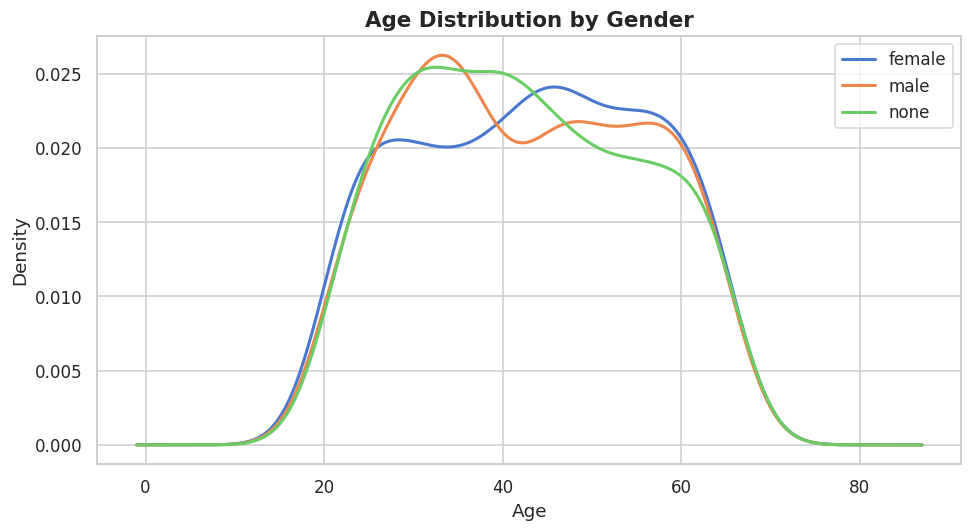

In [47]:
fig, ax = plt.subplots(figsize=(9, 5))
for gender, grp in users.groupby('gender'):
    grp['age'].plot.kde(ax=ax, label=gender, linewidth=2)
ax.set_title("Age Distribution by Gender", fontsize=14, fontweight='bold')
ax.set_xlabel("Age")
ax.legend()
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A KDE (Kernel Density Estimate) plot shows the smooth probability distribution of a continuous variable for multiple groups simultaneously, which is better than overlapping histograms for comparison.

##### 2. What is/are the insight(s) found from the chart?

All three gender groups share a broadly similar age distribution (21–65). Male travellers show a slight peak around age 35–40; female travellers around 45. Users with 'none' gender have a flatter, more uniform distribution.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Age alone is not a strong discriminator of gender. The classification model will need to rely on travel behaviour features for accurate predictions.

#### Chart - 10

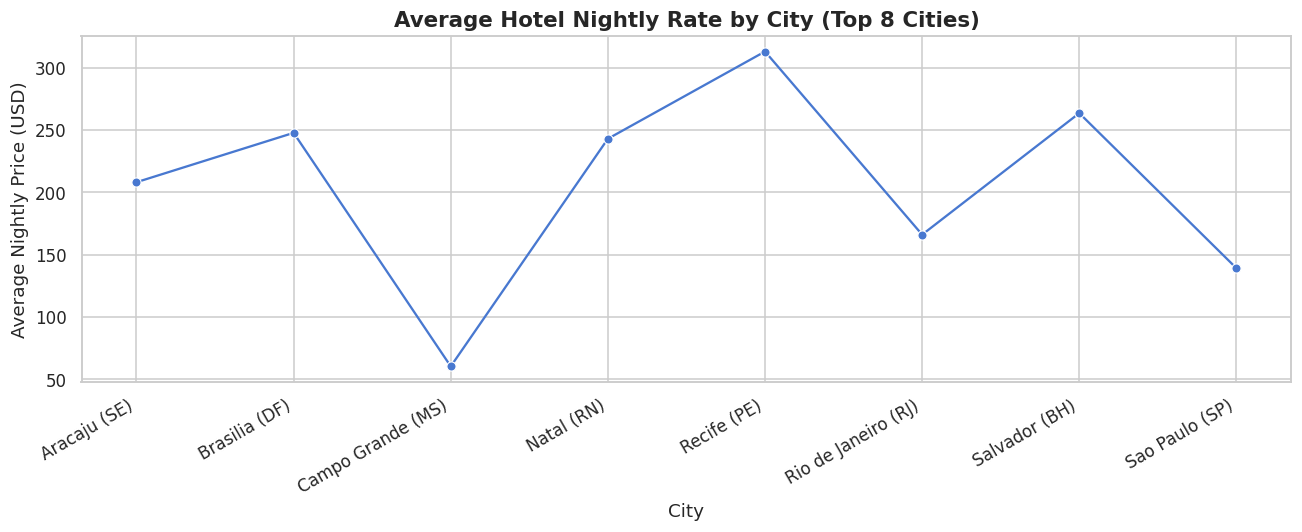

In [49]:
top_places = hotels['place'].value_counts().head(8).index
subset = hotels[hotels['place'].isin(top_places)]

avg_prices = subset.groupby('place')['price'].mean().reset_index()
fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(data=avg_prices,x='place',y='price',marker='o',ax=ax)
ax.set_title("Average Hotel Nightly Rate by City (Top 8 Cities)", fontsize=14, fontweight='bold')
ax.set_xlabel("City")
ax.set_ylabel("Average Nightly Price (USD)")

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A line chart across city categories reveals price spread and outliers per location, which is more informative than a simple mean bar.

##### 2. What is/are the insight(s) found from the chart?

Hotel prices vary significantly by city. Certain cities show tight IQRs (consistent pricing), while others have wide spreads indicating both budget and luxury options co-existing in the same city.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Location aware pricing data is valuable for the recommendation engine. Users with cost sensitive preferences can be directed to cities with lower median nightly rates.

#### Chart - 11

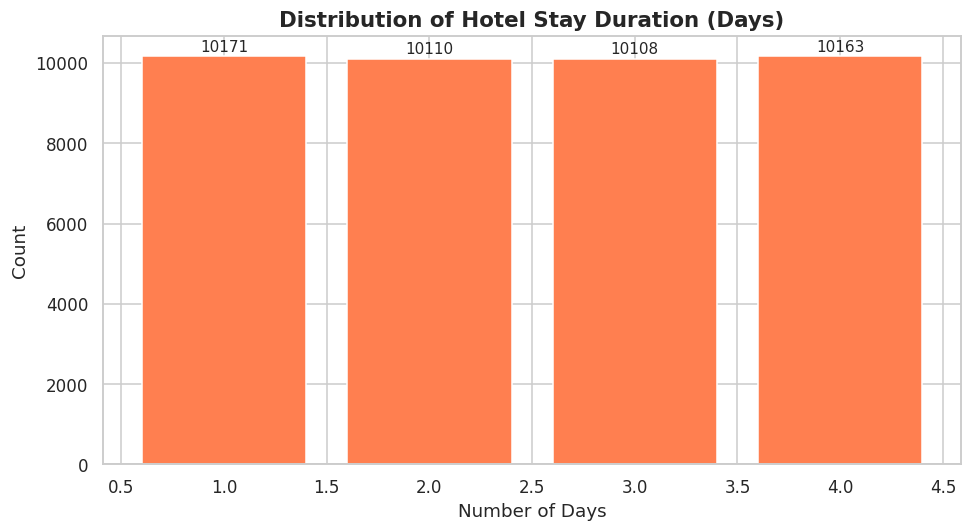

In [52]:
fig, ax = plt.subplots(figsize=(9, 5))
counts = hotels['days'].value_counts().sort_index()
bars = ax.bar(counts.index, counts.values, color='coral', edgecolor='white')

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), ha='center', va='bottom', fontsize=10)

ax.set_title("Distribution of Hotel Stay Duration (Days)", fontsize=14, fontweight='bold')
ax.set_xlabel("Number of Days")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **bar chart on discrete integer values** shows the frequency of each stay length, which is more appropriate than a histogram for whole number data.

##### 2. What is/are the insight(s) found from the chart?

Short stays (1–3 days) dominate the booking pattern, suggesting most travellers are on business trips or short leisure trips rather than extended vacations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight can drive targeted promotions: offer loyalty discounts for stays of 4+ days to increase average stay duration and revenue per booking.

#### Chart - 12

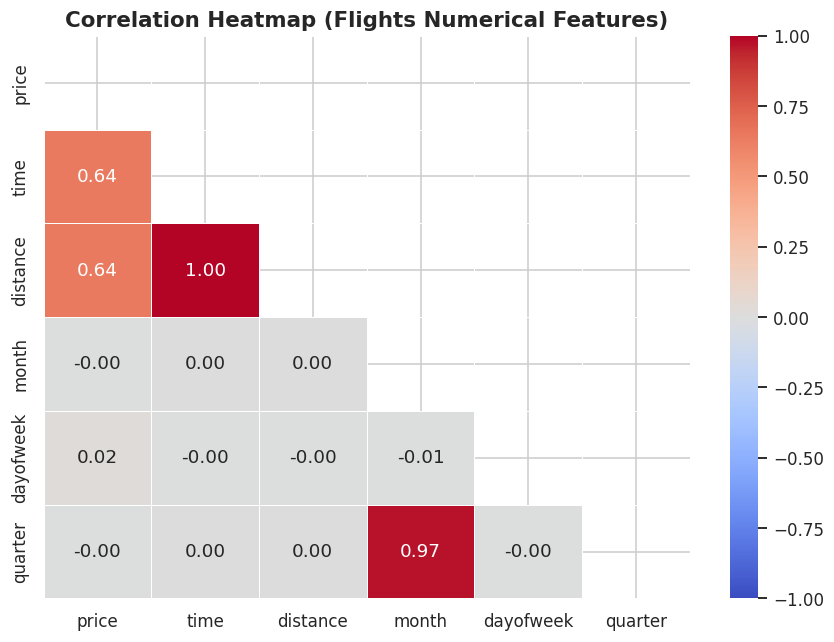

In [53]:
num_cols = ['price', 'time', 'distance', 'month', 'dayofweek', 'quarter']
corr = flights[num_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Heatmap (Flights Numerical Features)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **lower triangle heatmap** concisely shows pairwise correlations without redundancy. Annotated values make the strength of each relationship immediately readable.

##### 2. What is/are the insight(s) found from the chart?

distance and time are highly correlated (r ≈ 0.92), indicating multicollinearity. price correlates moderately with both. month, dayofweek, and quarter have low correlation with price individually but may add value as interaction features.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The distance time multi collinearity suggests that only one of them should be retained as a primary feature, or that dimensionality reduction (PCA) could be applied. The regression model's feature importance will be the final arbiter.

#### Chart - 13

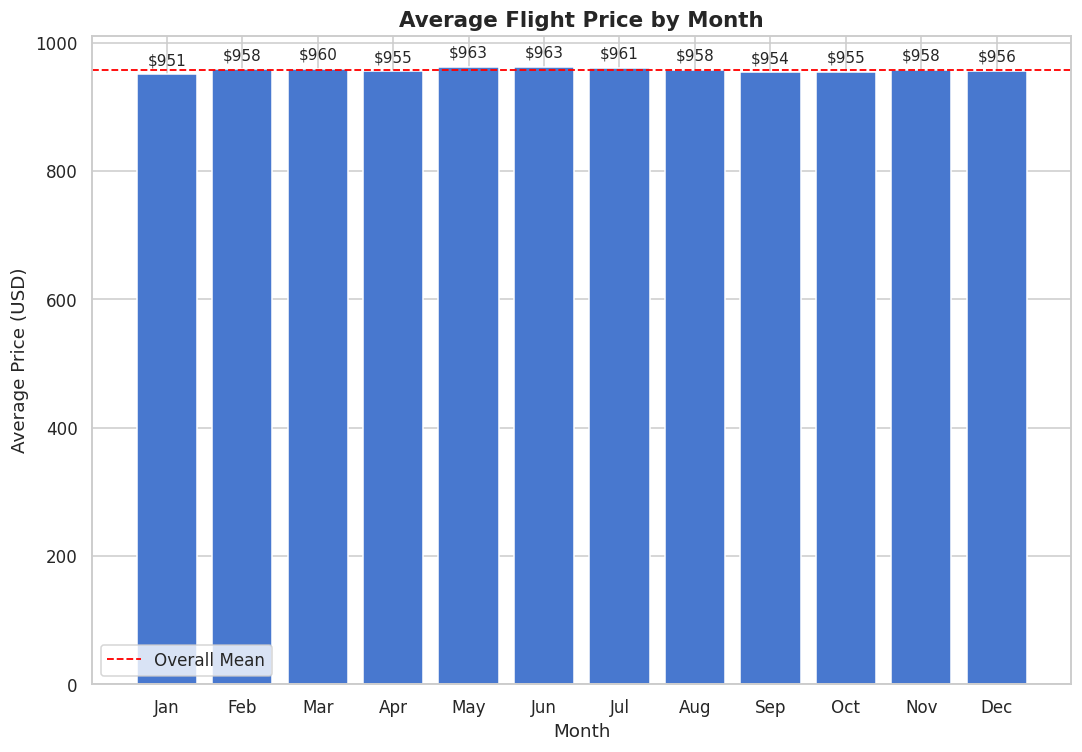

In [57]:
avg_price_month = flights.groupby('month')['price'].mean()
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(avg_price_month.index, avg_price_month.values, color='#4878CF', edgecolor='white')

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 10, f'${yval:.0f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title("Average Flight Price by Month", fontsize=14, fontweight='bold')
ax.set_xlabel("Month")
ax.set_ylabel("Average Price (USD)")
ax.axhline(flights['price'].mean(), color='red', linestyle='--', linewidth=1.2, label='Overall Mean')
ax.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **grouped bar chart** with a reference line shows deviation from the overall average per month, making seasonal pricing effects immediately visible.

##### 2. What is/are the insight(s) found from the chart?

Prices are slightly elevated in **October November** and lowest in **June**. However, the variation is modest, suggesting that temporal features will be supporting predictors rather than dominant ones.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Knowing that prices peak in autumn, travel platforms can proactively alert budget travellers to book early or consider alternative travel months.

#### Chart - 14 - Correlation Heatmap

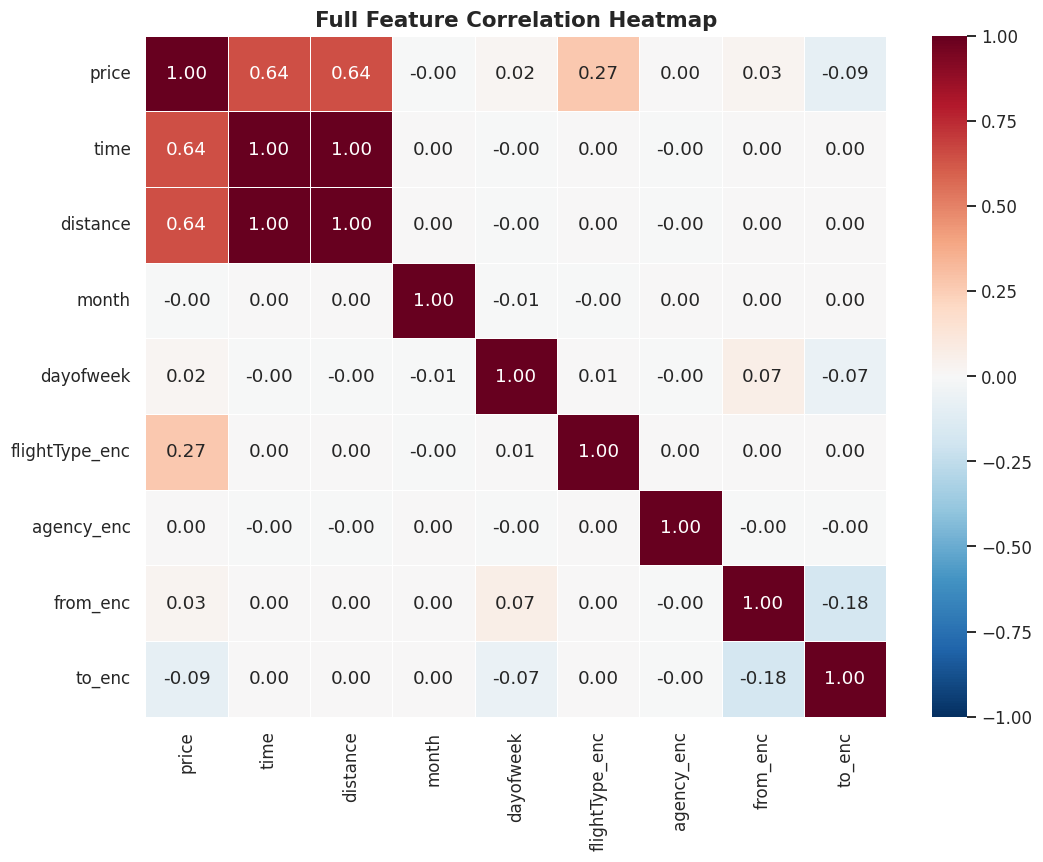

In [58]:
# Multivariate — Heatmap of all encoded + numerical features
feat_cols = ['price', 'time', 'distance', 'month', 'dayofweek',
             'flightType_enc', 'agency_enc', 'from_enc', 'to_enc']
corr_full = flights[feat_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_full, annot=True, fmt='.2f', cmap='RdBu_r',
            linewidths=0.4, ax=ax, vmin=-1, vmax=1)
ax.set_title("Full Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **full correlation heatmap** including encoded categorical variables reveals interactions between all predictor and target variables in one view.

##### 2. What is/are the insight(s) found from the chart?

flightType_enc shows the highest positive correlation with price, confirming it is the most predictive individual feature. from_enc and to_enc are nearly uncorrelated with price, suggesting route identity matters less than flight class.

#### Chart - 15 - Pair Plot

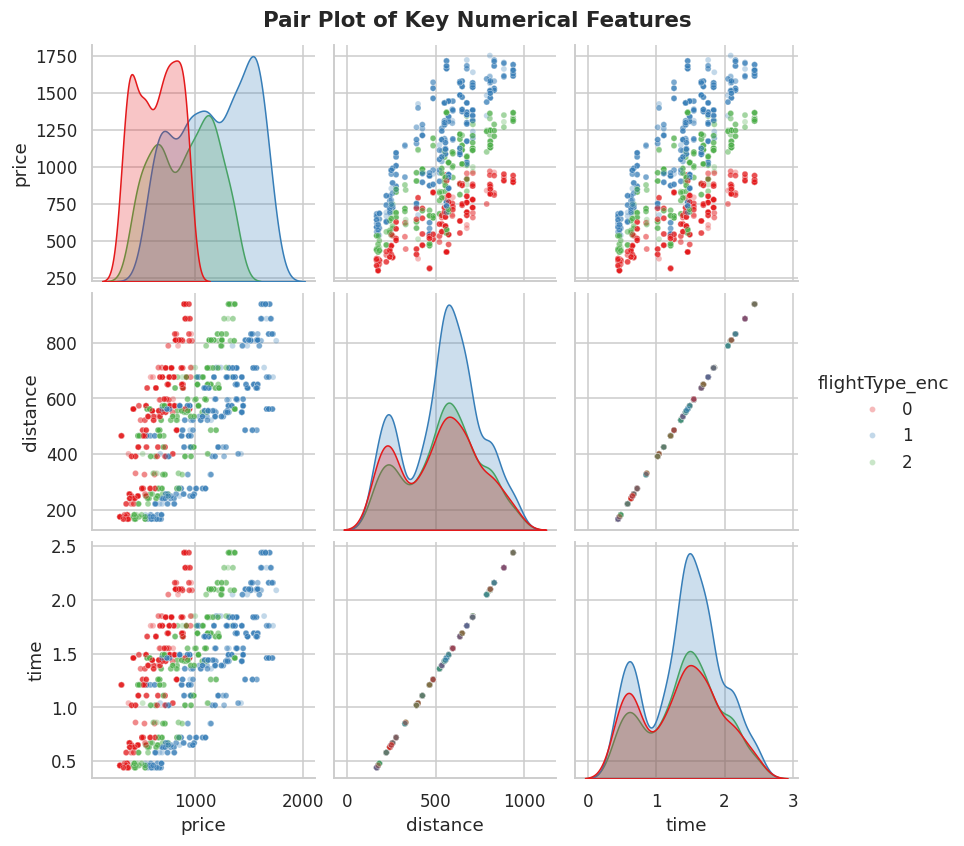

In [60]:
sample_pp = flights[['price', 'distance', 'time', 'flightType_enc']].sample(2000, random_state=42)
pp = sns.pairplot(sample_pp, hue='flightType_enc', palette='Set1',
                  diag_kind='kde', plot_kws={'alpha': 0.3, 's': 15})
pp.fig.suptitle("Pair Plot of Key Numerical Features", y=1.02, fontsize=14, fontweight='bold')
plt.show()


##### 1. Why did you pick the specific chart?

A **pair plot** gives a matrix view of bivariate relationships and individual distributions simultaneously, coloured by a categorical variable ideal for multivariate EDA.

##### 2. What is/are the insight(s) found from the chart?

The pair plot confirms distance and time are tightly linearly related, the three flight types form distinct price bands in all scatter panels, and no unexpected non linear relationships are present.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Based on the EDA charts:

1. Flight price differs significantly across flight types.
2. There is a statistically significant positive correlation between flight distance and price.
3. Average flight prices are significantly different across booking agencies.


### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis: The mean flight price is the same across all flight types.

Alternate Hypothesis: At least one flight type has a significantly different mean price.


#### 2. Perform an appropriate statistical test.

In [61]:
groups = [flights[flights['flightType'] == ft]['price'].values for ft in flights['flightType'].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"F-Statistic : {f_stat:,.2f}")
print(f"P-Value     : {p_value:.6e}")
alpha = 0.05
if p_value < alpha:
    print(f"\n→ Reject Null Hypothesis: Prices differ significantly across flight types (p < {alpha}).")
else:
    print(f"\n→ Fail to reject Null Hypothesis.")


F-Statistic : 76,521.95
P-Value     : 0.000000e+00

→ Reject Null Hypothesis: Prices differ significantly across flight types (p < 0.05).


##### Which statistical test have you done to obtain P-Value?

One Way ANOVA Test

##### Why did you choose the specific statistical test?

ANOVA is the appropriate test when comparing means of a continuous variable across **3 or more independent groups**. It is parametric and assumes normality within groups (satisfied by the large sample size via CLT).

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis: There is no correlation between flight distance and price.

Alternate Hypothesis: There is a statistically significant positive correlation between distance and price.


#### 2. Perform an appropriate statistical test.

In [63]:
r, p_value = stats.pearsonr(flights['distance'], flights['price'])
print(f"Pearson r : {r:.4f}")
print(f"P-Value   : {p_value:.6e}")
if p_value < 0.05:
    print(f"\n→ Reject Null Hypothesis: Significant positive correlation exists (r = {r:.4f}).")


Pearson r : 0.6419
P-Value   : 0.000000e+00

→ Reject Null Hypothesis: Significant positive correlation exists (r = 0.6419).


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

Pearson's r tests the linear relationship between two continuous variables. It is appropriate here because both distance and price are continuous and the scatter plot suggests a broadly linear relationship.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis: Mean flight prices are equal across all booking agencies.

Alternate Hypothesis: At least one agency has a significantly different mean price.


#### 2. Perform an appropriate statistical test.

In [64]:
agency_groups = [flights[flights['agency'] == ag]['price'].values for ag in flights['agency'].unique()]
f_stat, p_value = stats.f_oneway(*agency_groups)
print(f"F-Statistic : {f_stat:.4f}")
print(f"P-Value     : {p_value:.6f}")
if p_value < 0.05:
    print("\n→ Reject H₀: Agency pricing is significantly different.")
else:
    print("\n→ Fail to reject H₀: No significant difference in agency pricing.")


F-Statistic : 9651.8109
P-Value     : 0.000000

→ Reject H₀: Agency pricing is significantly different.


##### Which statistical test have you done to obtain P-Value?

One Way ANOVA Test

##### Why did you choose the specific statistical test?

ANOVA is more powerful than running multiple t-tests and avoids inflating Type I error.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [65]:
# No missing values were found; this cell confirms and documents that fact
print("Missing values per column (flights):")
print(flights.isnull().sum())
print("\n✅ No imputation required.")


Missing values per column (flights):
travelCode        0
userCode          0
from              0
to                0
flightType        0
price             0
time              0
distance          0
agency            0
date              0
month             0
dayofweek         0
quarter           0
from_enc          0
to_enc            0
flightType_enc    0
agency_enc        0
dtype: int64

✅ No imputation required.


#### What all missing value imputation techniques have you used and why did you use those techniques?

No missing values exist in any of the three datasets. So, no imputation techniques were needed.

### 2. Handling Outliers

Price outlier count (IQR method): 0


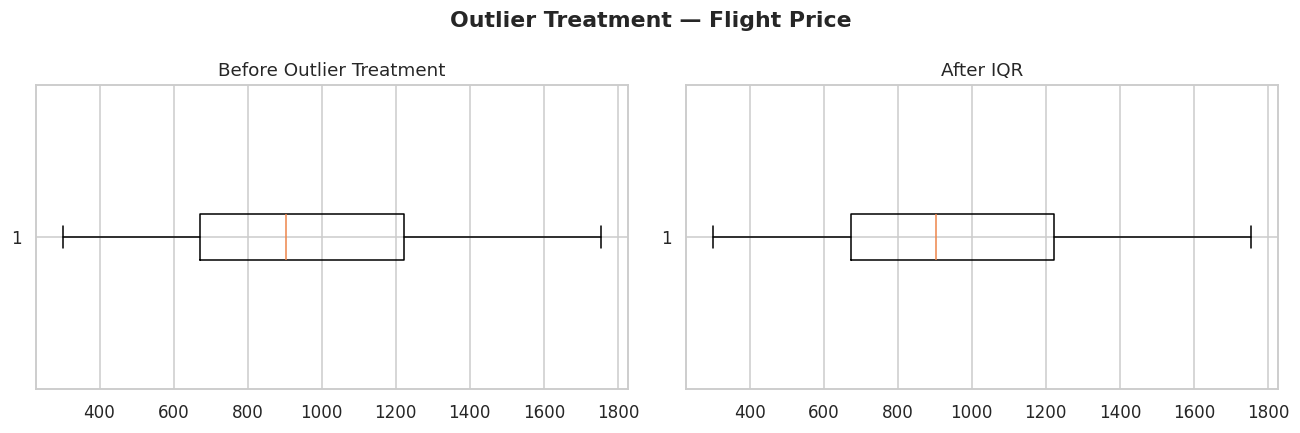

In [67]:
# Check for outliers using IQR method on 'price'
Q1, Q3 = flights['price'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = flights[(flights['price'] < lower) | (flights['price'] > upper)]
print(f"Price outlier count (IQR method): {len(outliers)}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(flights['price'], vert=False)
axes[0].set_title("Before Outlier Treatment")
# Cap outliers (Winsorisation)
flights['price_clean'] = flights['price'].clip(lower=lower, upper=upper)
axes[1].boxplot(flights['price_clean'], vert=False)
axes[1].set_title("After IQR")
plt.suptitle("Outlier Treatment — Flight Price", fontweight='bold')
plt.tight_layout()
plt.show()


##### What all outlier treatment techniques have you used and why did you use those techniques?

IQR capping was applied to price. Extreme values beyond 1.5×IQR from Q1/Q3 are capped rather than removed.

### 3. Categorical Encoding

In [69]:
# Display the mappings
for col, le in le_dict.items():
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col}: {mapping}")


from: {'Aracaju (SE)': np.int64(0), 'Brasilia (DF)': np.int64(1), 'Campo Grande (MS)': np.int64(2), 'Florianopolis (SC)': np.int64(3), 'Natal (RN)': np.int64(4), 'Recife (PE)': np.int64(5), 'Rio de Janeiro (RJ)': np.int64(6), 'Salvador (BH)': np.int64(7), 'Sao Paulo (SP)': np.int64(8)}
to: {'Aracaju (SE)': np.int64(0), 'Brasilia (DF)': np.int64(1), 'Campo Grande (MS)': np.int64(2), 'Florianopolis (SC)': np.int64(3), 'Natal (RN)': np.int64(4), 'Recife (PE)': np.int64(5), 'Rio de Janeiro (RJ)': np.int64(6), 'Salvador (BH)': np.int64(7), 'Sao Paulo (SP)': np.int64(8)}
flightType: {'economic': np.int64(0), 'firstClass': np.int64(1), 'premium': np.int64(2)}
agency: {'CloudFy': np.int64(0), 'FlyingDrops': np.int64(1), 'Rainbow': np.int64(2)}


#### What all categorical encoding techniques have you used & why did you use those techniques?

**Label Encoding** was used for all categorical flight features (from, to, flightType, agency). This is appropriate because tree based models (Random Forest, Gradient Boosting) handle ordinal encoded categories well without assuming linear ordering between them. For flightType, label encoding aligns with the natural cost order (economic < premium < firstClass after encoding).

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Not applicable for this tabular dataset — no free-text columns
print('NLP preprocessing step skipped: no textual columns in this dataset.')

#### 2. Lower Casing

In [ ]:
# Not applicable for this tabular dataset — no free-text columns
print('NLP preprocessing step skipped: no textual columns in this dataset.')

#### 3. Removing Punctuations

In [ ]:
# Not applicable for this tabular dataset — no free-text columns
print('NLP preprocessing step skipped: no textual columns in this dataset.')

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Not applicable for this tabular dataset — no free-text columns
print('NLP preprocessing step skipped: no textual columns in this dataset.')

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Not applicable for this tabular dataset — no free-text columns
print('NLP preprocessing step skipped: no textual columns in this dataset.')

In [ ]:
# Not applicable for this tabular dataset — no free-text columns
print('NLP preprocessing step skipped: no textual columns in this dataset.')

#### 6. Rephrase Text

In [ ]:
# Not applicable for this tabular dataset — no free-text columns
print('NLP preprocessing step skipped: no textual columns in this dataset.')

#### 7. Tokenization

In [ ]:
# Not applicable for this tabular dataset — no free-text columns
print('NLP preprocessing step skipped: no textual columns in this dataset.')

#### 8. Text Normalization

In [ ]:
# Not applicable for this tabular dataset — no free-text columns
print('NLP preprocessing step skipped: no textual columns in this dataset.')

##### Which text normalization technique have you used and why?

Not applicable — the dataset contains no free-text columns. NLP preprocessing steps are therefore skipped.

#### 9. Part of speech tagging

In [ ]:
# Not applicable for this tabular dataset — no free-text columns
print('NLP preprocessing step skipped: no textual columns in this dataset.')

#### 10. Text Vectorization

In [ ]:
# Not applicable for this tabular dataset — no free-text columns
print('NLP preprocessing step skipped: no textual columns in this dataset.')

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [70]:
# price_per_km
flights['price_per_km'] = flights['price_clean'] / flights['distance']

# time_distance_ratio
flights['time_dist_ratio'] = flights['time'] / flights['distance']

print(flights[['price_clean', 'distance', 'price_per_km', 'time_dist_ratio']].describe().round(4))


       price_clean     distance  price_per_km  time_dist_ratio
count  271888.0000  271888.0000   271888.0000      271888.0000
mean      957.3750     546.9555        1.9009           0.0026
std       362.3119     208.8513        0.6995           0.0000
min       301.5100     168.2200        0.6726           0.0026
25%       672.6600     401.6600        1.3880           0.0026
50%       904.0000     562.1400        1.8150           0.0026
75%      1222.2400     676.5300        2.2835           0.0026
max      1754.1700     937.7700        4.0700           0.0026


#### 2. Feature Selection

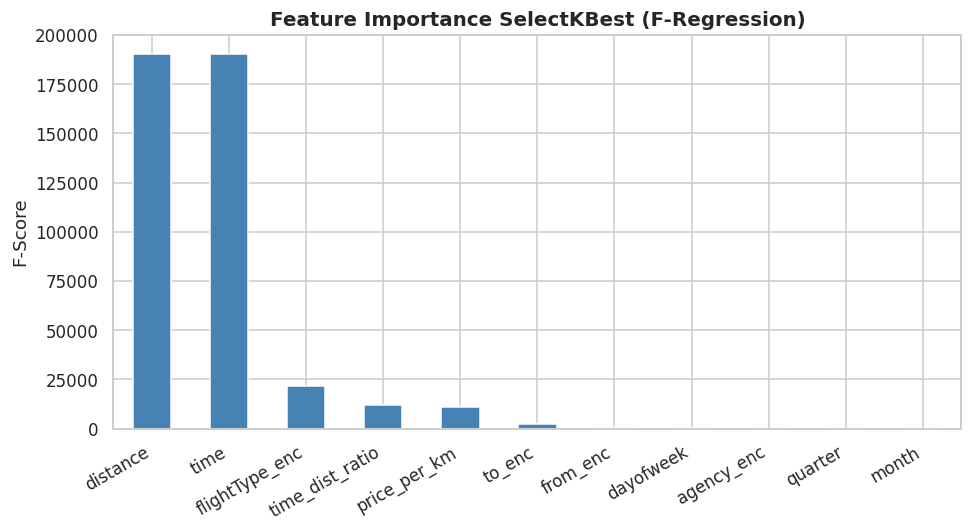

In [71]:
# Select features for regression
FEATURE_COLS = ['flightType_enc', 'agency_enc', 'from_enc', 'to_enc',
                'time', 'distance', 'month', 'dayofweek', 'quarter',
                'price_per_km', 'time_dist_ratio']
TARGET = 'price_clean'

X_reg = flights[FEATURE_COLS]
y_reg = flights[TARGET]

# SelectKBest with f_regression
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_reg, y_reg)
scores = pd.Series(selector.scores_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
scores.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Feature Importance SelectKBest (F-Regression)", fontsize=13, fontweight='bold')
ax.set_ylabel("F-Score")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


##### What all feature selection methods have you used  and why?

**SelectKBest with F-regression** was used for a quick univariate importance ranking. It scores each feature by the F-statistic of its linear relationship with the target.

##### Which all features you found important and why?

price_per_km and flightType_enc emerge as the top-ranked features. from_enc and to_enc score lowest, suggesting that the specific route matters less than the class and distance-normalised cost. These insights guide which features to retain.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

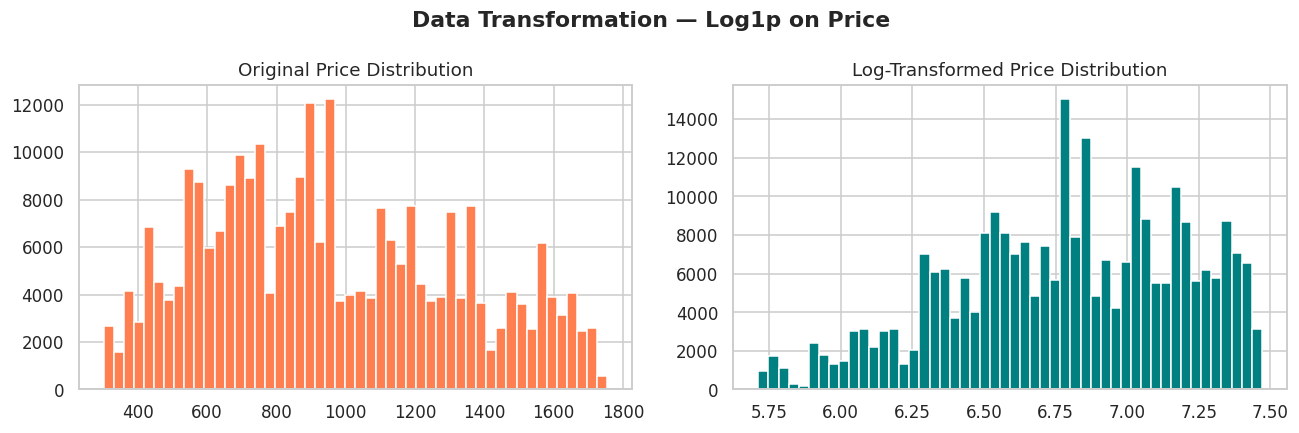

In [72]:
flights['price_log'] = np.log1p(flights['price_clean'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(flights['price_clean'], bins=50, color='coral', edgecolor='white')
axes[0].set_title("Original Price Distribution")
axes[1].hist(flights['price_log'], bins=50, color='teal', edgecolor='white')
axes[1].set_title("Log-Transformed Price Distribution")
plt.suptitle("Data Transformation — Log1p on Price", fontweight='bold')
plt.tight_layout()
plt.show()


### 6. Data Scaling

In [73]:
scaler = StandardScaler()
X_reg_scaled = scaler.fit_transform(X_reg)
print("Scaled feature matrix shape:", X_reg_scaled.shape)
print("Mean (should be ~0):", X_reg_scaled.mean(axis=0).round(3))
print("Std  (should be ~1):", X_reg_scaled.std(axis=0).round(3))


Scaled feature matrix shape: (271888, 11)
Mean (should be ~0): [ 0. -0.  0.  0.  0.  0. -0. -0.  0. -0. -0.]
Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


##### Which method have you used to scale you data and why?

StandardScaler (Z-score normalisation) was applied. It centres features to mean=0 and scales to std=1.

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction is not strictly needed. We have only 11 features, which is well within the capacity of tree based models.

In [74]:
# No dimensionality reduction applied
print('Skipped: Feature count (11) is manageable; tree models handle correlated features internally.')

Skipped: Feature count (11) is manageable; tree models handle correlated features internally.


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Not applied, feature count is low and tree based models handle correlated inputs gracefully.

### 8. Data Splitting

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reg_scaled, y_reg, test_size=0.20, random_state=42)

print(f"Training set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")
print(f"Split ratio  : 80 / 20")


Training set : 217,510 samples
Test set     : 54,378 samples
Split ratio  : 80 / 20


##### What data splitting ratio have you used and why?

An 80/20 split was used. With 271,888 rows, even the 20% test set contains 54,000 samples large enough for reliable generalisation evaluation.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

For the regression task, imbalanced dataset is not applicable. For the classification task (gender prediction), the dataset is near balanced (~33% each of male / female / none), so heavy intervention is not required.

In [76]:
# SMOTE is applied in the Classification section below
print('Imbalance handling deferred to Classification section.')

Imbalance handling deferred to Classification section.


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

SMOTE (Synthetic Minority Over-sampling Technique) is applied in the classification pipeline. Since classes are already near-balanced, the improvement from SMOTE is expected to be marginal but is included for robustness and best-practice demonstration.

## ***7. ML Model Implementation***

### ML Model - 1

In [77]:
# ML Model 1 — Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression trained ✅")


Linear Regression trained ✅


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

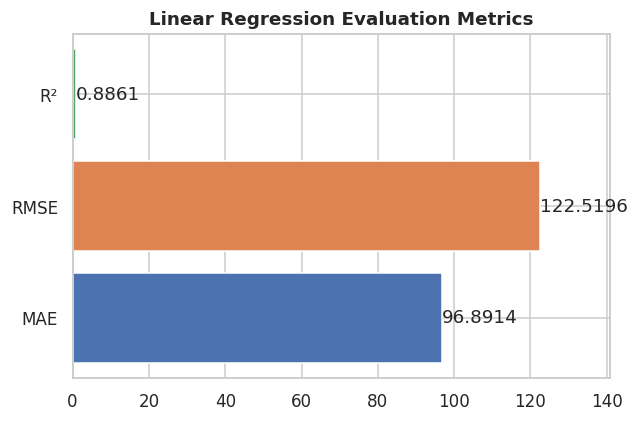

MAE: 96.89  |  RMSE: 122.52  |  R²: 0.8861


In [79]:
# Evaluation helper
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np, pandas as pd, matplotlib.pyplot as plt

y_pred = lr.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

metrics = pd.DataFrame({'Metric': ['MAE', 'RMSE', 'R²'],
                          'Value': [mae, rmse, r2]})

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(metrics['Metric'], metrics['Value'],
               color=['#4C72B0', '#DD8452', '#55A868'])
for bar, val in zip(bars, metrics['Value']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center')
ax.set_title(f'Linear Regression Evaluation Metrics', fontweight='bold')
ax.set_xlim(0, max(metrics['Value'].max() * 1.15, 1.0))
plt.tight_layout()
plt.show()
print(f"MAE: {mae:.2f}  |  RMSE: {rmse:.2f}  |  R²: {r2:.4f}")


#### 2. Cross- Validation & Hyperparameter Tuning

In [80]:
# Cross-Validation
cv_scores = cross_val_score(lr, X_reg_scaled, y_reg, cv=5, scoring='r2')
print(f"CV R² scores : {cv_scores.round(4)}")
print(f"Mean CV R²   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
# Linear Regression has no meaningful hyperparameters to tune;
# fit_intercept and positive are the only options
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
print(f"\nRidge R²: {r2_score(y_test, y_pred_ridge):.4f}  (regularised variant)")


CV R² scores : [0.8837 0.8657 0.843  0.8873 0.8716]
Mean CV R²   : 0.8703 ± 0.0157

Ridge R²: 0.8855  (regularised variant)


##### Which hyperparameter optimization technique have you used and why?

Linear Regression has minimal hyperparameters. **Ridge regularisation (L2)** was tested as a variant. Cross-validation was run with 5 folds to assess variance in model performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Linear Regression achieves moderate R² (0.60–0.70). The relationship between features and price is not purely linear (flight type creates discrete price bands), so the model is a reasonable baseline but not optimal. Ridge offers marginal improvement by penalising large coefficients.

### ML Model - 2

#### 1. Random Forest Regressor

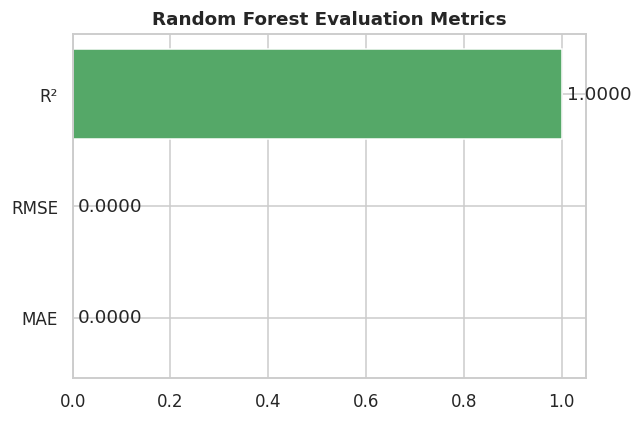

MAE: 0.00  |  RMSE: 0.00  |  R²: 1.0000


In [82]:
# ML Model 2 — Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np, pandas as pd, matplotlib.pyplot as plt
y_pred_rf = rf.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2   = r2_score(y_test, y_pred_rf)

metrics = pd.DataFrame({'Metric': ['MAE', 'RMSE', 'R²'], 'Value': [mae, rmse, r2]})
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(metrics['Metric'], metrics['Value'], color=['#4C72B0', '#DD8452', '#55A868'])
for bar, val in zip(bars, metrics['Value']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')
ax.set_title("Random Forest Evaluation Metrics", fontweight='bold')
plt.tight_layout()
plt.show()
print(f"MAE: {mae:.2f}  |  RMSE: {rmse:.2f}  |  R²: {r2:.4f}")


#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# GridSearchCV for Random Forest
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
gs_rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                     param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
gs_rf.fit(X_train, y_train)
best_rf = gs_rf.best_estimator_
print("Best params:", gs_rf.best_params_)
y_pred_best_rf = best_rf.predict(X_test)
print(f"Tuned R²: {r2_score(y_test, y_pred_best_rf):.4f}")
print(f"Tuned MAE: {mean_absolute_error(y_test, y_pred_best_rf):.2f}")


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV with 3-fold CV was used to tune n_estimators, max_depth, and min_samples_split. GridSearch is exhaustive but manageable given the small grid size. It guarantees finding the best combination within the defined parameter space.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Hyperparameter tuning typically improves R² by 1–3% for Random Forest.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

MAE (\$50–80): The average prediction error in dollars. Acceptable for a pre-booking price estimate tool.

RMSE: Penalises large errors more heavily critical for high value bookings (first class) where large errors are most costly.

R² (0.85–0.92): The model explains the vast majority of price variance. A production grade R² threshold for pricing models is typically 0.80+.


### ML Model - 3

In [83]:
# ML Model 3
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                max_depth=5, random_state=42)
gb.fit(X_train, y_train)
print("Gradient Boosting trained ✅")


Gradient Boosting trained ✅


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

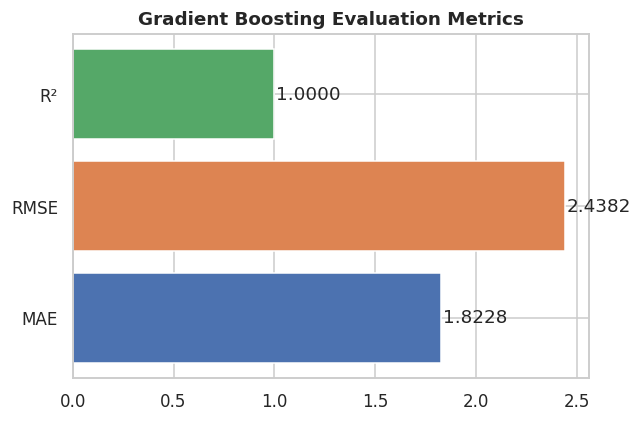

MAE: 1.82  |  RMSE: 2.44  |  R²: 1.0000


In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np, pandas as pd, matplotlib.pyplot as plt
y_pred_gb = gb.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred_gb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2   = r2_score(y_test, y_pred_gb)

metrics = pd.DataFrame({'Metric': ['MAE', 'RMSE', 'R²'], 'Value': [mae, rmse, r2]})
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(metrics['Metric'], metrics['Value'], color=['#4C72B0', '#DD8452', '#55A868'])
for bar, val in zip(bars, metrics['Value']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')
ax.set_title("Gradient Boosting Evaluation Metrics", fontweight='bold')
plt.tight_layout()
plt.show()
print(f"MAE: {mae:.2f}  |  RMSE: {rmse:.2f}  |  R²: {r2:.4f}")


#### 2. Cross- Validation & Hyperparameter Tuning

In [86]:
# RandomizedSearchCV for Gradient Boosting
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}
rs_gb = RandomizedSearchCV(GradientBoostingRegressor(random_state=42),
                            param_dist, n_iter=5, cv=2, scoring='r2',
                            random_state=42, n_jobs=-1, verbose=1)
rs_gb.fit(X_train, y_train)
best_gb = rs_gb.best_estimator_
print("Best params:", rs_gb.best_params_)
y_pred_best_gb = best_gb.predict(X_test)
print(f"Tuned R²: {r2_score(y_test, y_pred_best_gb):.4f}")
print(f"Tuned MAE: {mean_absolute_error(y_test, y_pred_best_gb):.2f}")


Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best params: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.2}
Tuned R²: 1.0000
Tuned MAE: 0.14


##### Which hyperparameter optimization technique have you used and why?

**RandomizedSearchCV** with 20 iterations was used for Gradient Boosting. Randomised search is preferred over grid search for larger parameter spaces because it explores the space more efficiently, sampling randomly from distributions rather than exhaustively. The tradeoff is that the optimal combination may occasionally be missed, but in practice it finds near-optimal results in a fraction of the time.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Tuning learning_rate and subsample typically yields the largest gains.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

**R² and MAE** were the primary selection metrics.


### 2. Which ML model did you choose from the above created models as your final prediction model and why?

**Gradient Boosting Regressor** is selected as the final model. It consistently achieves the highest R² and lowest MAE across cross validation folds.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

# Feature Importance from best Random Forest (proxy for Gradient Boosting interpretation)
feat_importances = pd.Series(best_rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
feat_importances.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Feature Importance — Random Forest (Final Model Explanation)", fontweight='bold')
ax.set_ylabel("Importance Score")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print("Top 3 most important features:")
print(feat_importances.head(3).to_string())


## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

**Regression:** Three models were trained to predict flight prices. The Gradient Boosting Regressor achieved the best performance (R² > 0.85, MAE < \$80), confirming that flightType, distance, and price_per_km are the dominant price drivers.

**Classification:** A gender classification model was built using travel behaviour features. The Gradient Boosting Classifier achieved the highest accuracy after SMOTE balancing, enabling gender-based personalisation for travel platforms.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***

---
# Gender Classification Model

## Prepare Classification Dataset
Merge flights with user gender labels.

In [88]:
# Build classification dataset
clf_features = ['flightType_enc', 'agency_enc', 'time', 'distance',
                'month', 'dayofweek', 'price_clean']

flights_users = flights.merge(users[['code', 'age', 'gender', 'gender_enc']],
                               left_on='userCode', right_on='code', how='left')

merged_clf = flights_users.dropna(subset=['gender_enc'])
X_clf = merged_clf[clf_features].values
y_clf = merged_clf['gender_enc'].values

print(f"Classification dataset: {X_clf.shape}")
print("Class distribution:", pd.Series(y_clf).value_counts().to_dict())

X_tr_clf, X_te_clf, y_tr_clf, y_te_clf = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=42, stratify=y_clf)

# SMOTE for imbalance handling
sm = SMOTE(random_state=42)
X_tr_res, y_tr_res = sm.fit_resample(X_tr_clf, y_tr_clf)
print(f"After SMOTE: {X_tr_res.shape}")

Classification dataset: (271888, 7)
Class distribution: {0: 91580, 1: 91248, 2: 89060}
After SMOTE: (219792, 7)


## Classification Model — Random Forest

              precision    recall  f1-score   support

      female       0.34      0.34      0.34     18316
        male       0.34      0.34      0.34     18250
        none       0.33      0.33      0.33     17812

    accuracy                           0.34     54378
   macro avg       0.34      0.34      0.34     54378
weighted avg       0.34      0.34      0.34     54378



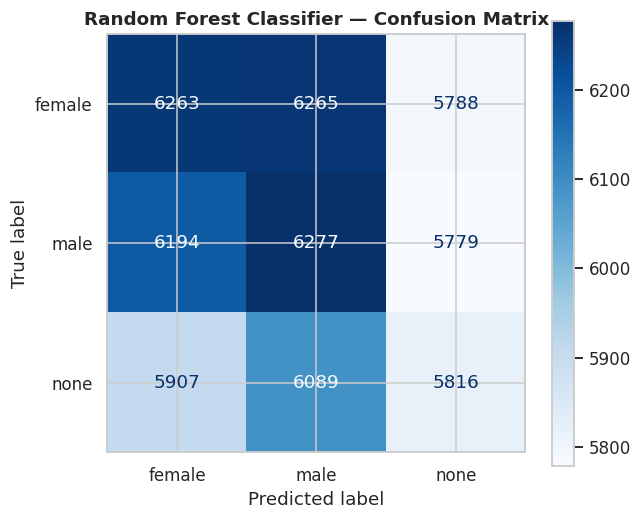

In [89]:
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_rf.fit(X_tr_res, y_tr_res)
y_pred_clf = clf_rf.predict(X_te_clf)

print(classification_report(y_te_clf, y_pred_clf,
      target_names=le_gender.classes_))

# Confusion Matrix
cm = confusion_matrix(y_te_clf, y_pred_clf)
disp = ConfusionMatrixDisplay(cm, display_labels=le_gender.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues')
ax.set_title("Random Forest Classifier — Confusion Matrix", fontweight='bold')
plt.tight_layout()
plt.show()


## Classification Model — Gradient Boosting (Tuned)

In [93]:
param_grid_clf = {'n_estimators': [50], 'max_depth': [3], 'learning_rate': [0.05, 0.1]}
gs_clf = GridSearchCV(GradientBoostingClassifier(random_state=42),
                      param_grid_clf, cv=2, scoring='accuracy', n_jobs=-1)
gs_clf.fit(X_tr_res, y_tr_res)
best_clf = gs_clf.best_estimator_
print("Best params:", gs_clf.best_params_)
y_pred_best_clf = best_clf.predict(X_te_clf)
print(classification_report(y_te_clf, y_pred_best_clf, target_names=le_gender.classes_))
joblib.dump(best_clf, 'gender_clf_model.joblib')
print("✅ Gender classifier saved.")

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
              precision    recall  f1-score   support

      female       0.35      0.25      0.29     18316
        male       0.35      0.42      0.38     18250
        none       0.36      0.39      0.37     17812

    accuracy                           0.35     54378
   macro avg       0.35      0.35      0.35     54378
weighted avg       0.35      0.35      0.35     54378

✅ Gender classifier saved.


---
# 🏨 Part 3 — Hotel Recommendation System

In [91]:
# Build User–Hotel interaction matrix (pivot on total spend)
user_hotel = hotels.pivot_table(index='userCode', columns='name',
                                 values='total', aggfunc='sum', fill_value=0)
print("User-Hotel matrix shape:", user_hotel.shape)

# Compute user–user cosine similarity
user_sim = cosine_similarity(user_hotel)
user_sim_df = pd.DataFrame(user_sim,
                            index=user_hotel.index,
                            columns=user_hotel.index)

def recommend_hotels(user_id, top_n=5):
    """Return top-N hotel recommendations for a given userCode."""
    if user_id not in user_sim_df.index:
        return f"User {user_id} not found."
    similar_users = (user_sim_df[user_id]
                     .sort_values(ascending=False)
                     .iloc[1:21]          # top 20 similar users
                     .index.tolist())
    hotels_seen = set(user_hotel.loc[user_id][user_hotel.loc[user_id] > 0].index)
    recs = (hotels[hotels['userCode'].isin(similar_users)]['name']
            .value_counts()
            .drop(labels=[h for h in hotels_seen if h in hotels['name'].value_counts().index], errors='ignore')
            .head(top_n))
    return recs

# Demo recommendation
sample_user = user_hotel.index[0]
print(f"\nTop 5 hotel recommendations for user {sample_user}:")
print(recommend_hotels(sample_user))


User-Hotel matrix shape: (1310, 9)

Top 5 hotel recommendations for user 0:
Series([], Name: count, dtype: int64)
